# 資料前處理

In [1]:
# 讀取資料
import pandas as pd

df_dailies = pd.read_csv('dailies.csv')
df_sleeps = pd.read_csv('sleeps.csv')
df_spo2 = pd.read_csv('sleeps_sleepSpo2.csv')
df_epochs = pd.read_csv('epochs.csv')

In [2]:
# 欄位正名

# 1. 處理 Dailies (日資料)
# 統一欄位名稱：把 _userId 改成 new_id，date 改成 calendarDate
df_dailies = df_dailies.rename(columns={'_userId': 'new_id', 'date': 'calendarDate'})
# 格式化：把日期文字變成真正的「時間物件」，這樣電腦才能排序
df_dailies['calendarDate'] = pd.to_datetime(df_dailies['calendarDate'])

# 2. 處理 Sleeps (睡眠資料)
df_sleeps = df_sleeps.rename(columns={'_userId': 'new_id', 'date': 'calendarDate'})
df_sleeps['calendarDate'] = pd.to_datetime(df_sleeps['calendarDate'])

# 3. 處理 Epochs (15分鐘詳細資料)
df_epochs = df_epochs.rename(columns={'_userId': 'new_id', 'date': 'calendarDate'})
df_epochs['calendarDate'] = pd.to_datetime(df_epochs['calendarDate'])

In [3]:
# 去重

# 清理 Dailies
# 按照「人 -> 日期 -> 開始時間」排序，越晚發生的排越後面
df_dailies = df_dailies.sort_values(by=['new_id', 'calendarDate', 'startTimeInSeconds'])

# drop_duplicates
# subset=['new_id', 'calendarDate'] 只要「人」跟「日期」一樣，就視為重複
# keep='last' 只留排在隊伍最後面那一筆 (也就是最新的)
df_dailies_clean = df_dailies.drop_duplicates(subset=['new_id', 'calendarDate'], keep='last')

# 清理 Sleeps
# 睡眠是用 summaryId (摘要ID) 來分辨的
df_sleeps = df_sleeps.sort_values(by=['new_id', 'calendarDate', 'summaryId'])
df_sleeps_clean = df_sleeps.drop_duplicates(subset=['summaryId'], keep='last')

# 清理 Epochs
# 這是每 15 分鐘一筆的資料，所以我們用「人 + 時間點」來判斷
df_epochs = df_epochs.sort_values(by=['new_id', 'startTimeInSeconds'])
df_epochs_clean = df_epochs.drop_duplicates(subset=['new_id', 'startTimeInSeconds'], keep='last')

print(f"Dailies: 原本 {len(df_dailies)} 筆 -> 清理後 {len(df_dailies_clean)} 筆")
print(f"Sleeps:  原本 {len(df_sleeps)} 筆 -> 清理後 {len(df_sleeps_clean)} 筆")
print(f"Epochs:  原本 {len(df_epochs)} 筆 -> 清理後 {len(df_epochs_clean)} 筆")

Dailies: 原本 6047 筆 -> 清理後 2296 筆
Sleeps:  原本 3976 筆 -> 清理後 3058 筆
Epochs:  原本 300669 筆 -> 清理後 208441 筆


In [4]:
# 增加血氧欄位

# 1. 處理血氧原始檔
# 把文字轉成數字
df_spo2['SleepSpo2'] = pd.to_numeric(df_spo2['SleepSpo2'], errors='coerce')

# 2. 濃縮數據
# 針對每一個 summaryId (每一次睡眠)，算出 min (最低血氧) 和 mean (平均血氧)
spo2_agg = df_spo2.groupby('summaryId')['SleepSpo2'].agg(['min', 'mean']).reset_index()

# 幫欄位取個名字
spo2_agg = spo2_agg.rename(columns={'min': 'minSpO2', 'mean': 'averageSpO2'})

# 3. 合體
# 把算好的血氧數據，貼回剛才清好的睡眠表 (df_sleeps_clean)
# how='left' 以睡眠表為主，有血氧就填，沒血氧就留空，不要把睡眠資料刪掉
df_sleep_master = pd.merge(df_sleeps_clean, spo2_agg, on='summaryId', how='left')

In [5]:
# 輸出整理好的檔案
df_dailies_clean.to_csv('cleaned_dailies.csv', index=False)
df_sleep_master.to_csv('cleaned_sleep_master.csv', index=False)
df_epochs_clean.to_csv('cleaned_epochs.csv', index=False)

In [6]:
# 計算人數
import pandas as pd

# 1. 讀取剛剛整理好的三個檔案
df_dailies_clean = pd.read_csv('cleaned_dailies.csv')
df_sleeps_clean = pd.read_csv('cleaned_sleep_master.csv')
df_epochs_clean = pd.read_csv('cleaned_epochs.csv')

# 2. 把三張表的人名 (ID) 抓出來變成三個圈圈 (Set)
# (把中文換成上面的英文變數)
users_day = set(df_dailies_clean['new_id'])
users_sleep = set(df_sleeps_clean['new_id'])
users_epoch = set(df_epochs_clean['new_id'])

# 3. 算總人數 (聯集 Union)：只要有出現都算
# "|" 這個符號代表 OR (或)
total_users = len(users_day | users_sleep | users_epoch)

# 4. 算核心樣本 (交集 Intersection)：三個圈圈重疊的部分
# "&" 這個符號代表 AND (且)
core_users = len(users_day & users_sleep & users_epoch)

print(f"人數統計")
print(f"1. 日活動資料 (Dailies) 人數: {len(users_day)}")
print(f"2. 睡眠資料 (Sleeps) 人數: {len(users_sleep)}")
print(f"3. 活動細節 (Epochs) 人數: {len(users_epoch)}")
print(f"--------------------------------")
print(f"總參與人數 (聯集 Union): {total_users} 人")
print(f"核心完整樣本 (交集 Intersection): {core_users} 人")

人數統計
1. 日活動資料 (Dailies) 人數: 78
2. 睡眠資料 (Sleeps) 人數: 74
3. 活動細節 (Epochs) 人數: 79
--------------------------------
總參與人數 (聯集 Union): 79 人
核心完整樣本 (交集 Intersection): 73 人


# 欄位選取與特徵工程

In [7]:
import pandas as pd
import numpy as np

# =========================================================
# Step 0｜讀取 A 清理完的三份資料（B 的正式輸入）
# =========================================================
dailies = pd.read_csv("cleaned_dailies.csv")
sleep = pd.read_csv("cleaned_sleep_master.csv")
epochs = pd.read_csv("cleaned_epochs.csv")

print("✅ Loaded files")
print("dailies rows:", len(dailies))
print("sleep rows:", len(sleep))
print("epochs rows:", len(epochs))

# =========================================================
# Step 1｜統一日期格式（確保三表能以 calendarDate 對齊）
# =========================================================
dailies["calendarDate"] = pd.to_datetime(dailies["calendarDate"], errors="coerce").dt.date
sleep["calendarDate"] = pd.to_datetime(sleep["calendarDate"], errors="coerce").dt.date
epochs["calendarDate"] = pd.to_datetime(epochs["calendarDate"], errors="coerce").dt.date

# =========================================================
# Step 2｜sleep → 先聚合成「人-日睡眠摘要」
# 目的：
#  - 解決同一人同一天可能多筆睡眠事件
#  - 讓後續深睡/REM/覺醒比例計算更合理
# 聚合規則：
#  - 睡眠階段時間：sum
#  - minSpO2：min
#  - averageSpO2：mean
# =========================================================
sleep_daily = sleep.groupby(["new_id", "calendarDate"], as_index=False).agg({
    "durationInSeconds": "sum",
    "deepSleepDurationInSeconds": "sum",
    "lightSleepDurationInSeconds": "sum",
    "remSleepInSeconds": "sum",
    "awakeDurationInSeconds": "sum",
    "minSpO2": "min",
    "averageSpO2": "mean"
})

print("✅ sleep_daily built")
print("sleep_daily rows:", len(sleep_daily))

# =========================================================
# Step 3｜避免欄位撞名（超關鍵）
# 因為 dailies 也有 durationInSeconds
# 所以把睡眠的總時長改成 sleep_durationInSeconds
# =========================================================
sleep_daily = sleep_daily.rename(columns={
    "durationInSeconds": "sleep_durationInSeconds"
})

# =========================================================
# Step 4｜建立 B 的「人-日主表」
# 用 dailies 當骨架，左合併睡眠摘要
# =========================================================
df = dailies.merge(
    sleep_daily,
    on=["new_id", "calendarDate"],
    how="left"
)

print("✅ daily master merged")
print("merged rows:", len(df))

# =========================================================
# Step 5｜B1 欄位準備：轉數值（避免字串干擾計算）
# =========================================================
num_cols = [
    # dailies: 壓力與活動
    "averageStressLevel",
    "highStressDurationInSeconds",
    "steps",
    "activeTimeInSeconds",

    # sleep_daily: 睡眠與血氧
    "sleep_durationInSeconds",
    "deepSleepDurationInSeconds",
    "lightSleepDurationInSeconds",
    "remSleepInSeconds",
    "awakeDurationInSeconds",
    "minSpO2",
    "averageSpO2"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# =========================================================
# Step 6｜B2 核心特徵：睡眠結構比例
# =========================================================
df["sleep_durationInSeconds"] = df["sleep_durationInSeconds"].replace(0, np.nan)

df["deep_ratio"] = df["deepSleepDurationInSeconds"] / df["sleep_durationInSeconds"]
df["rem_ratio"] = df["remSleepInSeconds"] / df["sleep_durationInSeconds"]
df["awake_ratio"] = df["awakeDurationInSeconds"] / df["sleep_durationInSeconds"]

# 直覺可讀版本（分鐘）
df["total_sleep_min"] = df["sleep_durationInSeconds"] / 60
df["deep_min"] = df["deepSleepDurationInSeconds"] / 60
df["rem_min"] = df["remSleepInSeconds"] / 60

# =========================================================
# Step 7｜B2 核心特徵：壓力比例
# =========================================================
df["high_stress_ratio"] = df["highStressDurationInSeconds"] / 86400

# =========================================================
# Step 8｜B2 核心特徵：活動量（保留原值 + 分鐘）
# =========================================================
df["active_time_min"] = df["activeTimeInSeconds"] / 60

# =========================================================
# Step 9｜B2 核心特徵：血氧（原值即可）
#  - minSpO2
#  - averageSpO2
# =========================================================

# =========================================================
# Step 10｜用 epochs 建立「上午/晚上活動比例」（加分關鍵）
# 你 epochs 有 _datetime，直接切時段
# =========================================================
epochs["_datetime"] = pd.to_datetime(epochs["_datetime"], errors="coerce")
epochs["hour"] = epochs["_datetime"].dt.hour

def bucket(h):
    if 6 <= h < 12:
        return "morning"
    elif 12 <= h < 18:
        return "afternoon"
    else:
        return "evening"

epochs["bucket"] = epochs["hour"].apply(bucket)
epochs["activeTimeInSeconds"] = pd.to_numeric(epochs["activeTimeInSeconds"], errors="coerce")

epoch_pivot = epochs.pivot_table(
    index=["new_id", "calendarDate"],
    columns="bucket",
    values="activeTimeInSeconds",
    aggfunc="sum"
).reset_index()

for c in ["morning", "afternoon", "evening"]:
    if c not in epoch_pivot.columns:
        epoch_pivot[c] = 0

epoch_pivot["epoch_active_total"] = epoch_pivot["morning"] + epoch_pivot["afternoon"] + epoch_pivot["evening"]
epoch_pivot["morning_ratio"] = epoch_pivot["morning"] / epoch_pivot["epoch_active_total"].replace(0, np.nan)
epoch_pivot["evening_ratio"] = epoch_pivot["evening"] / epoch_pivot["epoch_active_total"].replace(0, np.nan)

epoch_pivot = epoch_pivot[["new_id", "calendarDate", "morning_ratio", "evening_ratio"]]

df = df.merge(epoch_pivot, on=["new_id", "calendarDate"], how="left")

print("✅ morning/evening ratios added")

# =========================================================
# Step 11｜合理範圍清理（讓結果更穩、更像研究）
# =========================================================
ratio_cols = [
    "deep_ratio", "rem_ratio", "awake_ratio",
    "high_stress_ratio",
    "morning_ratio", "evening_ratio"
]

for c in ratio_cols:
    df.loc[(df[c] < 0) | (df[c] > 1), c] = np.nan

# 血氧合理範圍（保守）
df.loc[(df["minSpO2"] < 70) | (df["minSpO2"] > 100), "minSpO2"] = np.nan
df.loc[(df["averageSpO2"] < 70) | (df["averageSpO2"] > 100), "averageSpO2"] = np.nan

# =========================================================
# Step 12｜輸出 B 的最終交付檔
# 一人一天一列
# =========================================================
keep_cols = [
    "new_id", "calendarDate",

    # 壓力
    "averageStressLevel", "highStressDurationInSeconds", "high_stress_ratio",

    # 活動
    "steps", "activeTimeInSeconds", "active_time_min",

    # 睡眠摘要 + 比例
    "sleep_durationInSeconds", "total_sleep_min",
    "deepSleepDurationInSeconds", "deep_min",
    "remSleepInSeconds", "rem_min",
    "lightSleepDurationInSeconds",
    "awakeDurationInSeconds",
    "deep_ratio", "rem_ratio", "awake_ratio",

    # 血氧
    "minSpO2", "averageSpO2",

    # 活動節奏
    "morning_ratio", "evening_ratio"
]

B_features = df[keep_cols].copy()
B_features.to_csv("B_features_daily.csv", index=False)

print("✅ B DONE: B_features_daily.csv created")
print("rows:", len(B_features), "cols:", len(B_features.columns))

# =========================================================
# Step 13｜快速健康檢查（你要看到合理的範圍）
# =========================================================
print("\n=== Quick sanity check ===")
print(B_features[["deep_ratio","rem_ratio","awake_ratio","high_stress_ratio","morning_ratio","evening_ratio"]].describe())


✅ Loaded files
dailies rows: 2296
sleep rows: 3058
epochs rows: 208441
✅ sleep_daily built
sleep_daily rows: 1187
✅ daily master merged
merged rows: 2296
✅ morning/evening ratios added
✅ B DONE: B_features_daily.csv created
rows: 2296 cols: 23

=== Quick sanity check ===
        deep_ratio    rem_ratio  awake_ratio  high_stress_ratio  \
count  1012.000000  1012.000000  1012.000000        2063.000000   
mean      0.217692     0.135726     0.020410           0.051597   
std       0.138044     0.088297     0.025460           0.068032   
min       0.000000     0.000000     0.000000           0.000000   
25%       0.122779     0.077071     0.006384           0.004861   
50%       0.188215     0.136396     0.012720           0.026389   
75%       0.286277     0.184942     0.023965           0.071875   
max       1.000000     0.530398     0.225824           0.551389   

       morning_ratio  evening_ratio  
count    1970.000000    1970.000000  
mean        0.247145       0.506130  
std       

In [8]:
# 0. 匯入套件 & 讀取資料
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 讀取 B 同學做好的特徵表
file_path = "B_features_daily.csv"   # 修改成你實際檔案路徑
df = pd.read_csv(file_path)

# 轉成日期格式，方便判斷平日/週末
df["calendarDate"] = pd.to_datetime(df["calendarDate"])

In [9]:
# 1. 建衍生欄位（高壓/低壓、平日/週末、覺醒分鐘）
# ==========================================

# 1-1 高壓 vs 低壓：用 averageStressLevel 的中位數切
stress_median = df["averageStressLevel"].median()
df["StressLevel"] = np.where(df["averageStressLevel"] > stress_median,
                             "High", "Low")  # High / Low

# 1-2 平日 vs 週末（0–4: 平日，5–6: 週末）
df["weekday_num"] = df["calendarDate"].dt.weekday
df["WeekType"] = np.where(df["weekday_num"] >= 5,
                          "Weekend", "Weekday")

# 1-3 覺醒分鐘數（原本是秒）
df["awake_min"] = df["awakeDurationInSeconds"] / 60.0

In [10]:
# 2. 描述性統計表（C1）
#    平均、標準差、最小值、最大值
# ==========================================

from IPython.display import display  # 在 Colab 中漂亮顯示表格

# 壓力變數
stress_vars = [
    "averageStressLevel",
    "highStressDurationInSeconds",
    "high_stress_ratio"
]

# 活動變數
activity_vars = [
    "steps",
    "activeTimeInSeconds",
    "active_time_min",
    "morning_ratio",
    "evening_ratio"
]

# 睡眠變數
sleep_vars = [
    "sleep_durationInSeconds",
    "total_sleep_min",
    "deepSleepDurationInSeconds",
    "deep_min",
    "remSleepInSeconds",
    "rem_min",
    "lightSleepDurationInSeconds",
    "awakeDurationInSeconds",
    "awake_min",
    "deep_ratio",
    "rem_ratio",
    "awake_ratio"
]

# 血氧變數
spo2_vars = [
    "minSpO2",
    "averageSpO2"
]

# 合併全部要做描述統計的欄位
desc_vars = stress_vars + activity_vars + sleep_vars + spo2_vars

# 計算描述統計
desc_table = df[desc_vars].describe().T  # 變數當列
# 只留下 mean, std, min, max
desc_table = desc_table[["mean", "std", "min", "max"]].round(2)

print("===== 描述性統計（全部變數） =====")
display(desc_table)          # 這行：在 Colab 直接顯示表格

# 也同時匯出成 CSV
desc_table.to_csv("desc_stats_all.csv", encoding="utf-8-sig")


===== 描述性統計（全部變數） =====


,mean,std,min,max
averageStressLevel,29.47,16.51,-2.00,90.00
highStressDurationInSeconds,4457.97,5878.01,0.00,47640.00
high_stress_ratio,0.05,0.07,0.00,0.55
steps,5660.15,4389.62,0.00,25600.00
activeTimeInSeconds,6225.13,4648.20,0.00,23275.00
active_time_min,103.75,77.47,0.00,387.92
morning_ratio,0.25,0.05,0.00,0.62
evening_ratio,0.51,0.05,0.03,1.00
sleep_durationInSeconds,67521.94,38608.28,7560.00,297960.00
total_sleep_min,1125.37,643.47,126.00,4966.00


<Figure size 640x480 with 0 Axes>

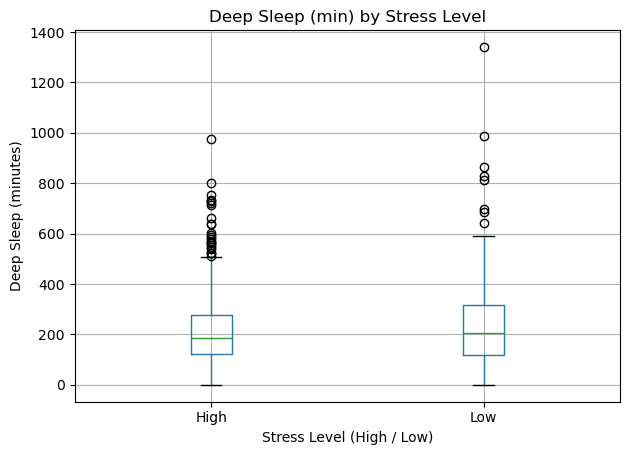

<Figure size 640x480 with 0 Axes>

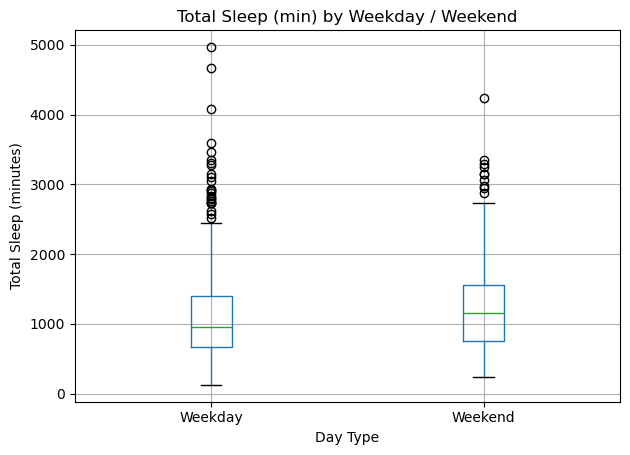

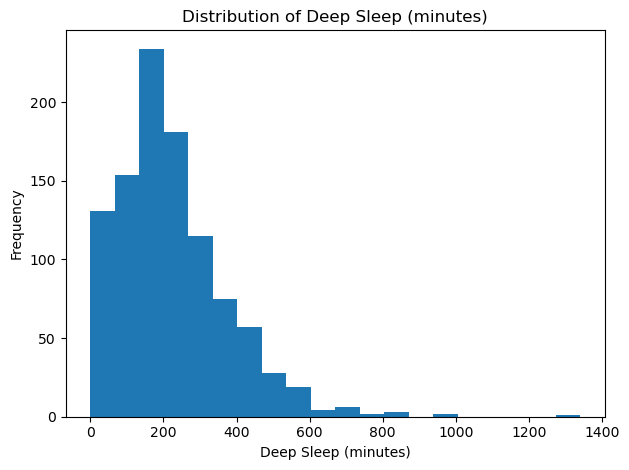

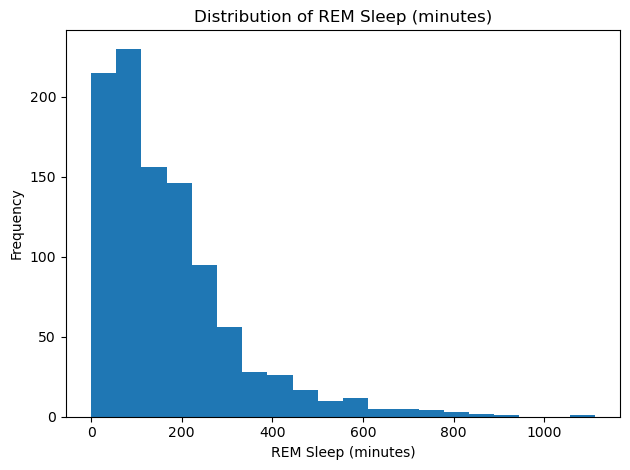

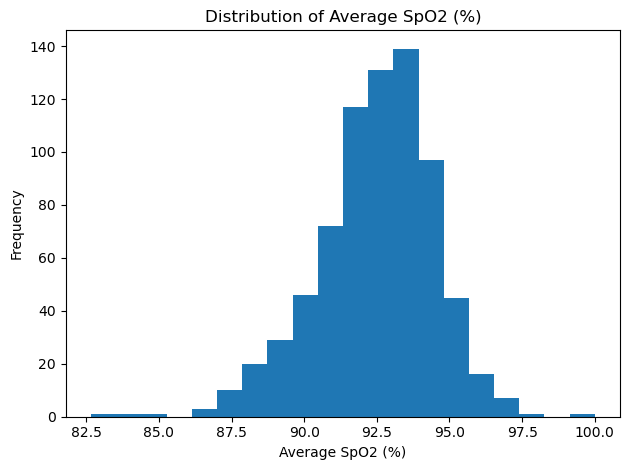

In [ ]:
# ==========================================
# 3. 視覺化（C2）
#    3-1 高壓 vs 低壓 → 深睡箱型圖
#    3-2 週末 vs 平日 → 總睡眠箱型圖
#    3-3 REM / Deep / SpO2 直方圖
# ==========================================

# 建議在 notebook 一開始加這行（通常 Colab 會自動幫你，但寫著比較安心）
# %matplotlib inline

# 3-1 高壓 vs 低壓 → 深睡箱型圖（用 deep_min，單位：分鐘）
plt.figure()
df.boxplot(column="deep_min", by="StressLevel")
plt.title("Deep Sleep (min) by Stress Level")
plt.suptitle("")  # 關掉 pandas 自動標題
plt.xlabel("Stress Level (High / Low)")
plt.ylabel("Deep Sleep (minutes)")
plt.tight_layout()
plt.savefig("box_deep_highlow_stress.png", dpi=300)  # 先存檔
plt.show()   # 再顯示在 Colab
plt.close()

# 3-2 週末 vs 平日 → 總睡眠箱型圖（用 total_sleep_min）
plt.figure()
df.boxplot(column="total_sleep_min", by="WeekType")
plt.title("Total Sleep (min) by Weekday / Weekend")
plt.suptitle("")
plt.xlabel("Day Type")
plt.ylabel("Total Sleep (minutes)")
plt.tight_layout()
plt.savefig("box_total_sleep_weekday_weekend.png", dpi=300)
plt.show()
plt.close()

# 3-3 直方圖：REM / Deep / SpO2
hist_vars = {
    "deep_min": "Deep Sleep (minutes)",
    "rem_min": "REM Sleep (minutes)",
    "averageSpO2": "Average SpO2 (%)"
}

for col, label in hist_vars.items():
    plt.figure()
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"hist_{col}.png", dpi=300)
    plt.show()
    plt.close()


資料中存在的欄位：
['new_id', 'calendarDate', 'averageStressLevel', 'highStressDurationInSeconds', 'high_stress_ratio', 'steps', 'activeTimeInSeconds', 'active_time_min', 'sleep_durationInSeconds', 'total_sleep_min', 'deepSleepDurationInSeconds', 'deep_min', 'remSleepInSeconds', 'rem_min', 'lightSleepDurationInSeconds', 'awakeDurationInSeconds', 'deep_ratio', 'rem_ratio', 'awake_ratio', 'minSpO2', 'averageSpO2', 'morning_ratio', 'evening_ratio', 'StressLevel', 'weekday_num', 'WeekType', 'awake_min']

相關矩陣使用的欄位：
['averageStressLevel', 'steps', 'active_time_min', 'deep_min', 'rem_min', 'awake_min', 'minSpO2', 'averageSpO2', 'morning_ratio', 'evening_ratio']

===== 相關係數矩陣 =====


,averageStressLevel,steps,active_time_min,deep_min,rem_min,awake_min,minSpO2,averageSpO2,morning_ratio,evening_ratio
averageStressLevel,1.00,0.25,0.27,-0.05,-0.02,-0.03,-0.02,-0.03,0.03,0.00
steps,0.25,1.00,0.95,0.09,0.02,0.10,-0.06,-0.03,-0.15,0.18
active_time_min,0.27,0.95,1.00,0.07,0.03,0.14,-0.05,-0.06,-0.16,0.21
deep_min,-0.05,0.09,0.07,1.00,0.18,0.17,-0.03,-0.01,0.03,0.12
rem_min,-0.02,0.02,0.03,0.18,1.00,0.36,-0.01,0.04,-0.01,-0.03
awake_min,-0.03,0.10,0.14,0.17,0.36,1.00,-0.01,0.03,0.04,-0.02
minSpO2,-0.02,-0.06,-0.05,-0.03,-0.01,-0.01,1.00,0.60,0.04,-0.05
averageSpO2,-0.03,-0.03,-0.06,-0.01,0.04,0.03,0.60,1.00,-0.11,0.05
morning_ratio,0.03,-0.15,-0.16,0.03,-0.01,0.04,0.04,-0.11,1.00,-0.42
evening_ratio,0.00,0.18,0.21,0.12,-0.03,-0.02,-0.05,0.05,-0.42,1.00


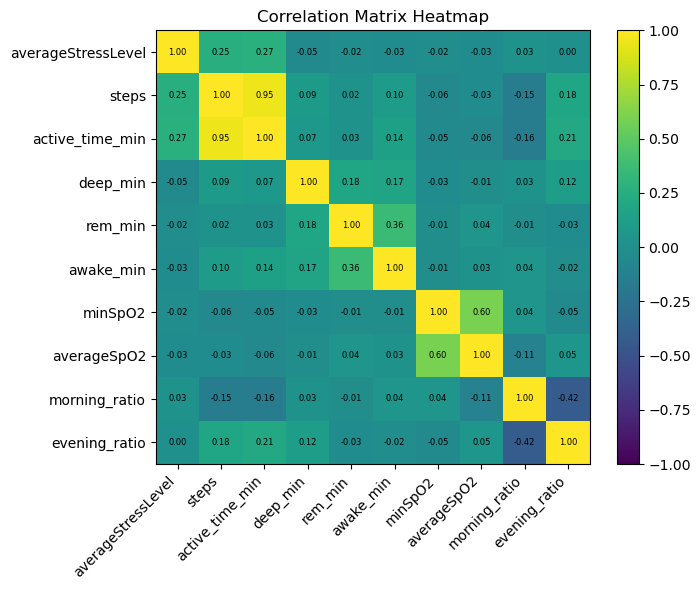

In [ ]:
# ==========================================
# C3. 相關係數矩陣（Correlation Matrix + Heatmap）
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 要放進相關矩陣的變數
corr_vars = [
    "averageStressLevel",   # Stress
    "steps",                # Steps
    "active_time_min",      # ActiveTime
    "deep_min",             # Deep
    "rem_min",              # REM
    "awake_min",            # Awake（前面有用 awakeDurationInSeconds / 60 算出來）
    "minSpO2",              # SpO2 (min)
    "averageSpO2",          # SpO2 (avg)
    "morning_ratio",        # Morning activity ratio
    "evening_ratio"         # Evening activity ratio
]

# 先確認這些欄位真的都在 df 裡面（出問題比較好 debug）
print("資料中存在的欄位：")
print(df.columns.tolist())
print("\n相關矩陣使用的欄位：")
print(corr_vars)

# 計算 Pearson 相關係數
corr_matrix = df[corr_vars].corr(method="pearson").round(2)

print("\n===== 相關係數矩陣 =====")
display(corr_matrix)   # 在 Colab 以表格形式顯示

# ==========================================
# 畫熱力圖（Heatmap）
# ==========================================
plt.figure(figsize=(8, 6))

# imshow 畫相關矩陣，固定範圍 -1～1
im = plt.imshow(corr_matrix, vmin=-1, vmax=1)

# 加上色階條
plt.colorbar(im, fraction=0.046, pad=0.04)

# 設定 x, y 軸標籤
plt.xticks(
    ticks=range(len(corr_vars)),
    labels=corr_vars,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=range(len(corr_vars)),
    labels=corr_vars
)

# 在每一格中間標出數值
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        value = corr_matrix.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha="center", va="center", fontsize=6
        )

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()



===== C4 成果輸出 =====

1. 描述統計完整表格 desc_stats_all.csv 已產生 ✔️


,mean,std,min,max
averageStressLevel,29.47,16.51,-2.00,90.00
highStressDurationInSeconds,4457.97,5878.01,0.00,47640.00
high_stress_ratio,0.05,0.07,0.00,0.55
steps,5660.15,4389.62,0.00,25600.00
activeTimeInSeconds,6225.13,4648.20,0.00,23275.00
active_time_min,103.75,77.47,0.00,387.92
morning_ratio,0.25,0.05,0.00,0.62
evening_ratio,0.51,0.05,0.03,1.00
sleep_durationInSeconds,67521.94,38608.28,7560.00,297960.00
total_sleep_min,1125.37,643.47,126.00,4966.00



2. 相關係數矩陣 corr_matrix.csv 已產生 ✔️


,averageStressLevel,steps,active_time_min,deep_min,rem_min,awake_min,minSpO2,averageSpO2,morning_ratio,evening_ratio
averageStressLevel,1.00,0.25,0.27,-0.05,-0.02,-0.03,-0.02,-0.03,0.03,0.00
steps,0.25,1.00,0.95,0.09,0.02,0.10,-0.06,-0.03,-0.15,0.18
active_time_min,0.27,0.95,1.00,0.07,0.03,0.14,-0.05,-0.06,-0.16,0.21
deep_min,-0.05,0.09,0.07,1.00,0.18,0.17,-0.03,-0.01,0.03,0.12
rem_min,-0.02,0.02,0.03,0.18,1.00,0.36,-0.01,0.04,-0.01,-0.03
awake_min,-0.03,0.10,0.14,0.17,0.36,1.00,-0.01,0.03,0.04,-0.02
minSpO2,-0.02,-0.06,-0.05,-0.03,-0.01,-0.01,1.00,0.60,0.04,-0.05
averageSpO2,-0.03,-0.03,-0.06,-0.01,0.04,0.03,0.60,1.00,-0.11,0.05
morning_ratio,0.03,-0.15,-0.16,0.03,-0.01,0.04,0.04,-0.11,1.00,-0.42
evening_ratio,0.00,0.18,0.21,0.12,-0.03,-0.02,-0.05,0.05,-0.42,1.00



3. 熱力圖 corr_heatmap.png 已產生（如下方應已顯示） ✔️


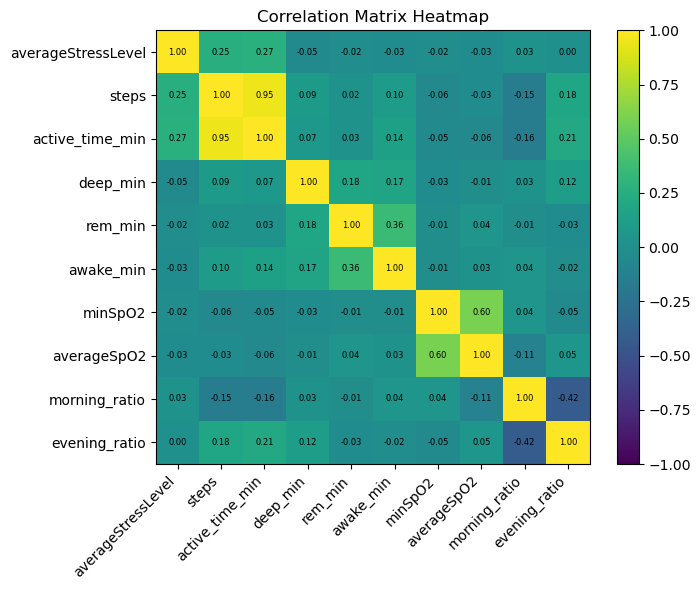

In [ ]:
# ==========================================
# C4. 成果彙整區（所有輸出匯總）
# ==========================================

print("===== C4 成果輸出 =====")

print("\n1. 描述統計完整表格 desc_stats_all.csv 已產生 ✔️")
display(desc_table)

print("\n2. 相關係數矩陣 corr_matrix.csv 已產生 ✔️")
display(corr_matrix)

print("\n3. 熱力圖 corr_heatmap.png 已產生（如下方應已顯示） ✔️")

# 額外顯示一次熱力圖（方便老師在 Colab 直接看到）
plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_vars)), corr_vars, rotation=45, ha="right")
plt.yticks(range(len(corr_vars)), corr_vars)
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        plt.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                 ha="center", va="center", fontsize=6)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


# 迴歸分析

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# 讀入資料
df = pd.read_csv("B_features_daily.csv")
df['calendarDate'] = pd.to_datetime(df['calendarDate'], errors='coerce')
df = df.sort_values(['new_id','calendarDate']).reset_index(drop=True)

=== RQ1 Simple regression ===
                            OLS Regression Results                            
Dep. Variable:               deep_min   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.883
Date:                Tue, 16 Dec 2025   Prob (F-statistic):             0.0898
Time:                        15:25:10   Log-Likelihood:                -6519.5
No. Observations:                1012   AIC:                         1.304e+04
Df Residuals:                    1010   BIC:                         1.305e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

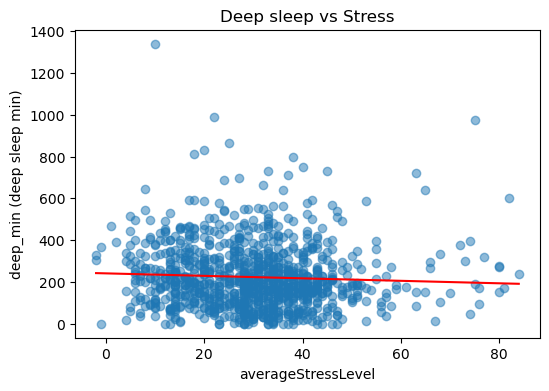

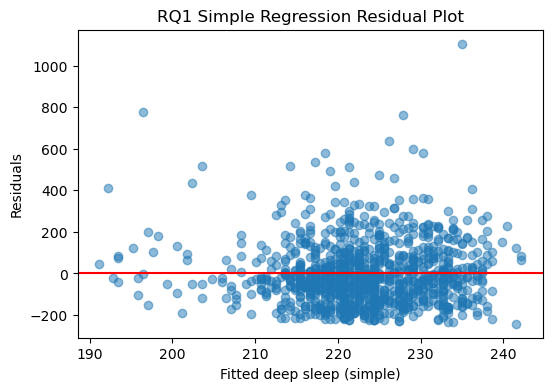

=== RQ1 Multiple regression ===
                            OLS Regression Results                            
Dep. Variable:               deep_min   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     6.868
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           0.000141
Time:                        15:25:11   Log-Likelihood:                -5880.4
No. Observations:                 915   AIC:                         1.177e+04
Df Residuals:                     911   BIC:                         1.179e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
cons

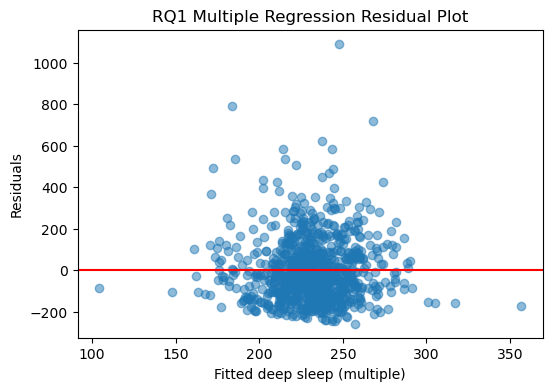

C:\Users\b7869\anaconda3\Lib\site-packages\statsmodels\graphics\regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)
C:\Users\b7869\anaconda3\Lib\site-packages\statsmodels\graphics\regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)
C:\Users\b7869\anaconda3\Lib\site-packages\statsmodels\graphics\regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (

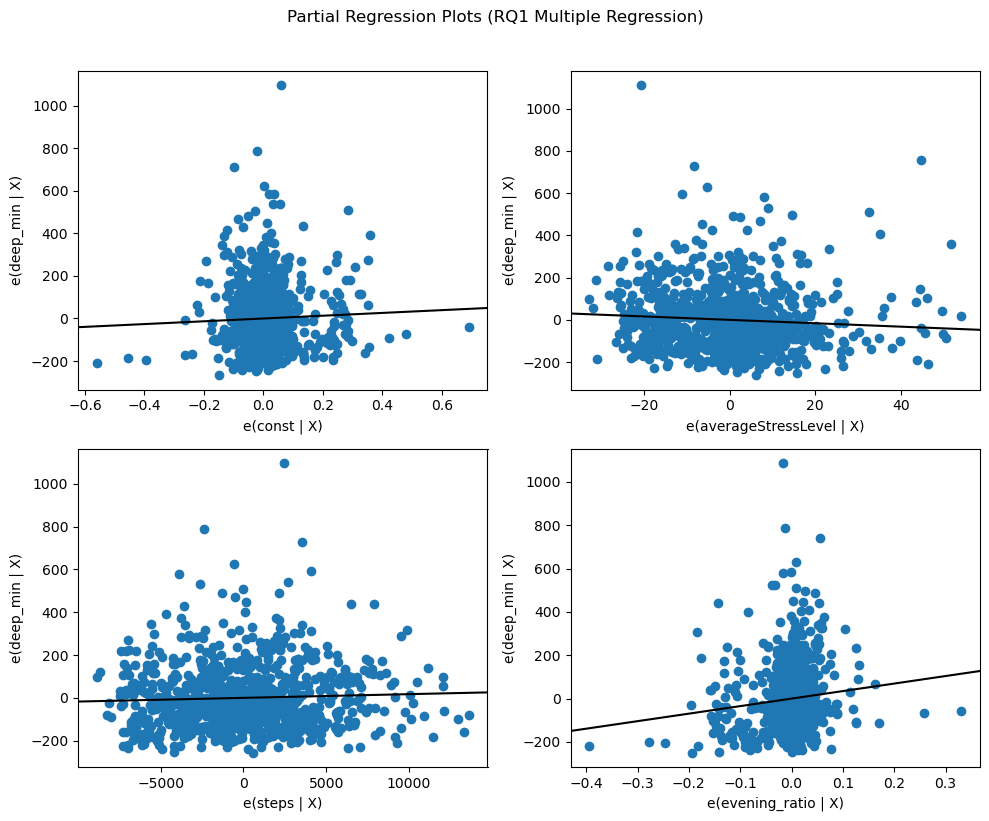

In [ ]:
# --- RQ1: 壓力 → 深睡 (simple & multiple regression) ---
# 確保欄位是 numeric
for col in ['averageStressLevel','deep_min','steps','evening_ratio']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# -------------------------
# RQ1-1 Simple regression
# -------------------------
m1_df = df[['deep_min','averageStressLevel']].dropna()
X1 = sm.add_constant(m1_df['averageStressLevel'])
y1 = m1_df['deep_min']
model1 = sm.OLS(y1, X1).fit()
print("=== RQ1 Simple regression ===")
print(model1.summary())

# --- 簡單迴歸：scatter + regression line ---
plt.figure(figsize=(6,4))
plt.scatter(m1_df['averageStressLevel'], m1_df['deep_min'], alpha=0.5)
xs = np.linspace(m1_df['averageStressLevel'].min(), m1_df['averageStressLevel'].max(), 100)
ys = model1.params['const'] + model1.params['averageStressLevel'] * xs
plt.plot(xs, ys, color='red')
plt.xlabel('averageStressLevel')
plt.ylabel('deep_min (deep sleep min)')
plt.title('Deep sleep vs Stress')
plt.show()

# --- 簡單迴歸：殘差圖 ---
plt.figure(figsize=(6,4))
plt.scatter(model1.fittedvalues, model1.resid, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Fitted deep sleep (simple)")
plt.ylabel("Residuals")
plt.title("RQ1 Simple Regression Residual Plot")
plt.show()


# -------------------------
# RQ1-2 Multiple regression
# -------------------------
m1b_df = df[['deep_min','averageStressLevel','steps','evening_ratio']].dropna()
X1b = sm.add_constant(m1b_df[['averageStressLevel','steps','evening_ratio']])
y1b = m1b_df['deep_min']
model1b = sm.OLS(y1b, X1b).fit()
print("=== RQ1 Multiple regression ===")
print(model1b.summary())

# --- 複迴歸：殘差圖 ---
plt.figure(figsize=(6,4))
plt.scatter(model1b.fittedvalues, model1b.resid, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Fitted deep sleep (multiple)")
plt.ylabel("Residuals")
plt.title("RQ1 Multiple Regression Residual Plot")
plt.show()

# --- 複迴歸：部分迴歸圖（Partial Regression Plots）---
fig = plt.figure(figsize=(10,8))
sm.graphics.plot_partregress_grid(model1b, fig=fig)
plt.suptitle("Partial Regression Plots (RQ1 Multiple Regression)", y=1.02)
plt.tight_layout()
plt.show()

=== RQ2 Descriptive Statistics ===
                           deep_min                    awake_min             \
                               mean         std count       mean        std   
stress_type                                                                   
Consecutive High Stress  214.330097  125.015010   103  22.368932  21.460858   
Single High Stress       228.422764  166.170415   123  20.853659  32.054432   

                               
                        count  
stress_type                    
Consecutive High Stress   103  
Single High Stress        123  


C:\Users\b7869\AppData\Local\Temp\ipykernel_16992\1906882339.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('stress_type')[['deep_min', 'awake_min']]


<Figure size 600x400 with 0 Axes>

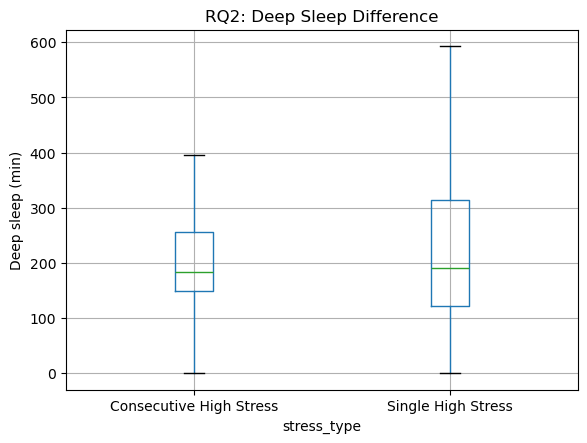

<Figure size 600x400 with 0 Axes>

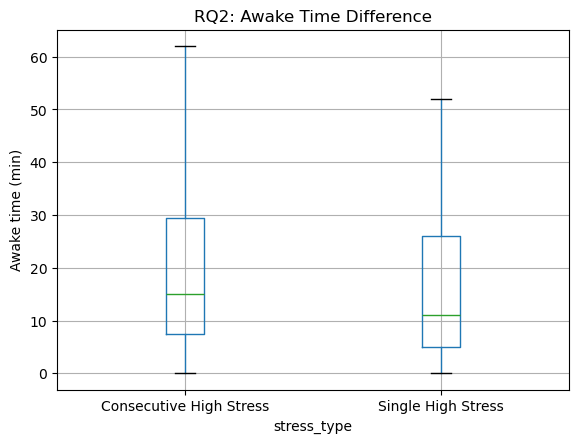

In [ ]:
# ======================================================
# RQ2：壓力累積效果
# 連續高壓日 vs 單次高壓日 的睡眠差異
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 確保 awake_min 一定存在（從 seconds 轉換，避免欄位不一致） ---
if 'awake_min' not in df.columns:
    df['awake_min'] = df['awakeDurationInSeconds'] / 60
else:
    df['awake_min'] = pd.to_numeric(df['awake_min'], errors='coerce')

# --- 必要欄位轉 numeric ---
for col in ['averageStressLevel', 'deep_min', 'awake_min']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- 定義高壓日（壓力分布前 25%） ---
stress_thr = df['averageStressLevel'].quantile(0.75)
df['high_stress'] = df['averageStressLevel'] >= stress_thr

# --- 依個體與日期排序 ---
df = df.sort_values(['new_id', 'calendarDate']).reset_index(drop=True)

# --- 判斷前一日是否為高壓日 ---
df['prev_high_stress'] = df.groupby('new_id')['high_stress'].shift(1)

# --- 分類壓力型態 ---
df['stress_type'] = np.where(
    (df['high_stress']) & (df['prev_high_stress'] == True),
    'Consecutive High Stress',
    np.where(
        (df['high_stress']) & (df['prev_high_stress'] == False),
        'Single High Stress',
        np.nan
    )
)

# --- 僅保留可明確分類的觀測值（完全移除 nan） ---
rq2_df = df.dropna(subset=['stress_type']).copy()

# --- 明確指定類別（避免 nan 被畫進來） ---
rq2_df['stress_type'] = pd.Categorical(
    rq2_df['stress_type'],
    categories=['Consecutive High Stress', 'Single High Stress'],
    ordered=True
)

# ======================================================
# 描述統計
# ======================================================
print("=== RQ2 Descriptive Statistics ===")
print(
    rq2_df
    .groupby('stress_type')[['deep_min', 'awake_min']]
    .agg(['mean', 'std', 'count'])
)

# ======================================================
# 視覺化
# ======================================================

# --- 深睡時間 ---
plt.figure(figsize=(6, 4))
rq2_df.boxplot(column='deep_min', by='stress_type', showfliers=False)
plt.ylabel('Deep sleep (min)')
plt.title('RQ2: Deep Sleep Difference')
plt.suptitle('')
plt.show()

# --- 清醒時間 ---
plt.figure(figsize=(6, 4))
rq2_df.boxplot(column='awake_min', by='stress_type', showfliers=False)
plt.ylabel('Awake time (min)')
plt.title('RQ2: Awake Time Difference')
plt.suptitle('')
plt.show()

In [ ]:
# --- RQ3: 週末恢復 → 下一週一壓力 (使用 週末加總) ---
df['weekday'] = df['calendarDate'].dt.weekday  # Monday = 0, Sunday = 6

mondays = df[df['weekday']==0].copy()

# 建 weekend sum
records = []
for idx, row in mondays.iterrows():
    nid = row['new_id']
    mon = row['calendarDate']
    sat = mon - pd.Timedelta(days=2)
    sun = mon - pd.Timedelta(days=1)
    try:
        sat_row = df[(df['new_id']==nid) & (df['calendarDate']==sat)].iloc[0]
        sun_row = df[(df['new_id']==nid) & (df['calendarDate']==sun)].iloc[0]
    except:
        continue
    ws = sat_row.get('total_sleep_min', np.nan) + sun_row.get('total_sleep_min', np.nan)
    wd = sat_row.get('deep_min', np.nan) + sun_row.get('deep_min', np.nan)
    wst = sat_row.get('steps', np.nan) + sun_row.get('steps', np.nan)
    records.append({'idx': idx, 'weekendSleep_sum': ws, 'weekendDeep_sum': wd, 'weekendSteps_sum': wst})

weekend_df = pd.DataFrame(records).set_index('idx')
mondays = mondays.join(weekend_df, how='inner')

mondays = mondays.dropna(subset=['weekendSleep_sum','weekendDeep_sum','weekendSteps_sum','averageStressLevel'])
X2 = sm.add_constant(mondays[['weekendSleep_sum','weekendDeep_sum','weekendSteps_sum']])
y2 = mondays['averageStressLevel']  # MondayStress = averageStressLevel on Monday
model2 = sm.OLS(y2, X2).fit()
print("=== RQ3 Regression (weekend sum → Monday stress) ===")
print(model2.summary())

=== RQ3 Regression (weekend sum → Monday stress) ===
                            OLS Regression Results                            
Dep. Variable:     averageStressLevel   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.5868
Date:                Tue, 16 Dec 2025   Prob (F-statistic):              0.625
Time:                        15:30:52   Log-Likelihood:                -381.12
No. Observations:                  93   AIC:                             770.2
Df Residuals:                      89   BIC:                             780.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [ ]:
# --- RQ3: 週末恢復 → 下一週一壓力 (使用 週末平均) ---

df["sleep_avg"] = df["total_sleep_min"]
df["deep_avg"] = df["deep_min"]
df["rem_avg"] = df["rem_min"]
df["active_avg"] = df["active_time_min"]
df["spo2_avg"] = df["averageSpO2"]
df["morning_avg"] = df["morning_ratio"]
df["evening_avg"] = df["evening_ratio"]

# --- 要丟進回歸的欄位 ---
X = df[[
    "sleep_avg","deep_avg","rem_avg","active_avg",
    "spo2_avg","morning_avg","evening_avg"
]]
y = df["averageStressLevel"]

# --- 清理所有 inf / NaN，用「該欄位平均」補所有 NaN ---
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())
y = y.replace([np.inf, -np.inf], np.nan).fillna(y.mean())

# --- 加上截距 ---
X = sm.add_constant(X)

# --- 跑 OLS（一定能成功） ---
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     averageStressLevel   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     28.85
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           2.41e-38
Time:                        15:30:56   Log-Likelihood:                -9597.1
No. Observations:                2296   AIC:                         1.921e+04
Df Residuals:                    2288   BIC:                         1.926e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          22.6584     27.476      0.825      

C:\Users\b7869\AppData\Local\Temp\ipykernel_16992\1844517836.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_plot['Variable'], rotation=45, ha='right')


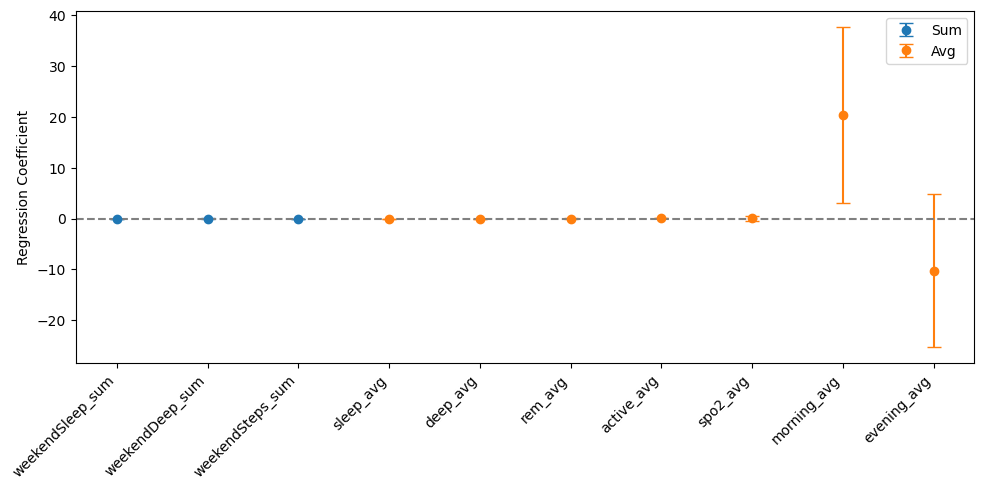

In [ ]:
# --- RQ3: 週末加總 vs 週末平均 比較---
# 整理數據
coeffs_sum = model2.params  # weekend sum model
conf_sum = model2.conf_int()  # 95% CI

coeffs_avg = model.params  # weekend avg model
conf_avg = model.conf_int()

variables = ['weekendSleep_sum','weekendDeep_sum','weekendSteps_sum']
coeff_data = []

for var in variables:
    coeff_data.append({
        'Variable': var,
        'Model': 'Sum',
        'Coef': coeffs_sum[var],
        'Lower': conf_sum.loc[var,0],
        'Upper': conf_sum.loc[var,1]
    })

for var in ['sleep_avg','deep_avg','rem_avg','active_avg','spo2_avg','morning_avg','evening_avg']:
    coeff_data.append({
        'Variable': var,
        'Model': 'Avg',
        'Coef': coeffs_avg[var],
        'Lower': conf_avg.loc[var,0],
        'Upper': conf_avg.loc[var,1]
    })

df_plot = pd.DataFrame(coeff_data)

# 畫圖
fig, ax = plt.subplots(figsize=(10,5))
for model in df_plot['Model'].unique():
    subset = df_plot[df_plot['Model']==model]
    ax.errorbar(subset['Variable'], subset['Coef'],
                yerr=[subset['Coef']-subset['Lower'], subset['Upper']-subset['Coef']],
                fmt='o', label=model, capsize=5)

ax.axhline(0, color='grey', linestyle='--')
ax.set_ylabel('Regression Coefficient')
ax.set_xticklabels(df_plot['Variable'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

比較各自變數的係數（含誤差線:95% 信賴區間）<br>
可以直接看到 **哪個變數在兩種模型下效果比較大或小**，誤差線也能顯示不顯著的變數。

C:\Users\b7869\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\b7869\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\b7869\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\b7869\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

最佳群數： 3
Silhouette score: 0.29250061722268744


C:\Users\b7869\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


=== K-means cluster centroids ===
   averageStressLevel        steps  deep_ratio
0           22.104972  6893.446573    0.323931
1           36.157804  6796.889655    0.150205
2           19.313433   153.174971    0.230929


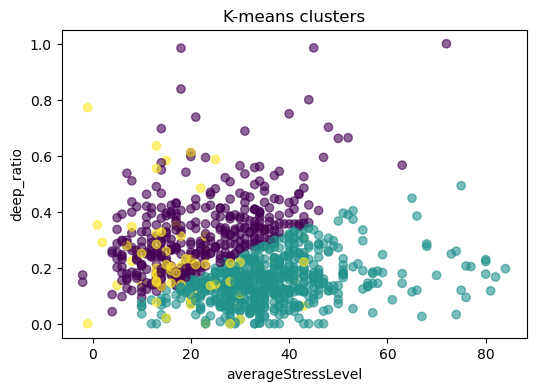

In [ ]:
# --- RQ4: K-means 分群（壓力 + 活動量 + 深睡比例） ---
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
# 數值處理
df['deep_ratio'] = pd.to_numeric(df.get('deep_ratio', None), errors='coerce')

# 步數做 log 轉換（避免右偏）
df['steps_log'] = np.log1p(df['steps'])

clust_df = df[['averageStressLevel','steps_log','deep_ratio']].dropna()

# 標準化
scaler = StandardScaler()
clust_scaled = scaler.fit_transform(clust_df)

# ---- 找最佳群數（silhouette）----
best_k = 2
best_score = -1

for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(clust_scaled)
    score = silhouette_score(clust_scaled, km.labels_)
    if score > best_score:
        best_score = score
        best_k = k

print("最佳群數：", best_k)
print("Silhouette score:", best_score)

# ---- 用最佳群數做分群 ----
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(clust_scaled)
clust_df['cluster'] = kmeans.labels_

# ---- 如果要讓群更明顯，加 PCA ----
pca = PCA(n_components=2)
pca_components = pca.fit_transform(clust_scaled)
clust_df['pc1'] = pca_components[:, 0]
clust_df['pc2'] = pca_components[:, 1]

# ---- 還原 centroid（好看解讀）----
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=['averageStressLevel','steps_log','deep_ratio'])

# 把 log 步數還原
centroids_df['steps'] = np.expm1(centroids_df['steps_log'])

print("=== K-means cluster centroids ===")
print(centroids_df[['averageStressLevel','steps','deep_ratio']])

# 畫 cluster 散點圖（stress vs deep_ratio）
plt.figure(figsize=(6,4))
plt.scatter(clust_df['averageStressLevel'], clust_df['deep_ratio'], c=clust_df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('averageStressLevel')
plt.ylabel('deep_ratio')
plt.title('K-means clusters')
plt.show()

三群：<br>
Group 0 (紫色點 - Healthly Active):<br>
* 特徵： 壓力低 (22.1)，步數高 (6893)，深睡比例最高 (0.32)。
* 畫像： 這是 **「健康活躍族群」**。運動量足夠，壓力小，睡眠質量最好。<br>
<br>
Group 1 (青色點 - Stressed Active):<br>
* 特徵： 壓力高 (36.1)，步數高 (6796)，深睡比例最低 (0.15)。
* 畫像： 這是 **「高壓勞碌族群」**。雖然活動量跟 Group 0 差不多，但因為壓力大，導致深睡比例受到嚴重影響（從 0.32 掉到 0.15）。這完美印證了壓力對睡眠的負面影響。<br>
<br>
Group 2 (黃色點 - Sedentary):<br>
* 特徵： 壓力低 (19.3)，步數極低 (153)，深睡中等 (0.23)。
* 畫像： 這是 **「久坐/無活動族群」**。可能是沒戴手錶走路，或是真的不動。這群人被單獨拉出來，是非常正確的，因為他們的生理模式跟有運動的人不一樣。

=== High performance day top 10% sample ===
     calendarDate    new_id  averageStressLevel  steps  deep_ratio  rem_ratio  \
207    2020-04-21  x33563ee                 4.0   7713    0.252600   0.195394   
237    2020-05-21  x33563ee                10.0   7445    0.209677   0.226815   
495    2020-05-17  x33b5ef9                16.0   7569    0.263793   0.225000   
1471   2021-12-01  x437ff9d                19.0   7018    0.196501   0.250336   
744    2020-10-31  x369ff0c                13.0   7273    0.352941   0.127251   
822    2020-10-24  x369ffb1                 8.0   7027    0.435247   0.084112   
1464   2021-11-24  x437ff9d                23.0   6781    0.205978   0.316439   
484    2020-05-06  x33b5ef9                12.0   7298    0.259740   0.123967   
136    2020-05-25  x3355ecf                 8.0   7230    0.272336   0.114101   
535    2020-05-06  x33b5f37                14.0   7294    0.295042   0.162031   
183    2020-05-21  x335606d                18.0   7443    0.28816

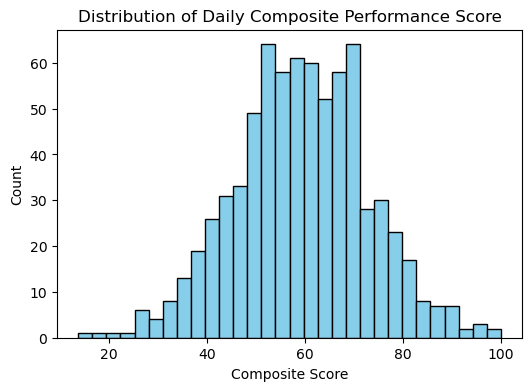

In [ ]:
# --- RQ5: 每日效能分數模型（Composite Score） ---
df['rem_ratio'] = pd.to_numeric(df.get('rem_ratio', None), errors='coerce')
df['averageSpO2'] = pd.to_numeric(df.get('averageSpO2', None), errors='coerce')

hp = df[['calendarDate','new_id','averageStressLevel','steps','deep_ratio','rem_ratio','averageSpO2']].copy().dropna()

hp['stress_pct'] = hp['averageStressLevel'].rank(pct=True)
hp['deep_pct'] = hp['deep_ratio'].rank(pct=True)
hp['rem_pct'] = hp['rem_ratio'].rank(pct=True)
hp['spO2_pct'] = hp['averageSpO2'].rank(pct=True)
hp['steps_pct'] = hp['steps'].rank(pct=True)

median_steps = hp['steps_pct'].median()
hp['activity_score'] = 1 - (hp['steps_pct'] - median_steps).abs()*2
hp['activity_score'] = hp['activity_score'].clip(lower=0, upper=1)

# composite score，加權可依妳研究設計改
hp['composite'] = (1 - hp['stress_pct'])*0.25 + hp['activity_score']*0.2 + hp['deep_pct']*0.25 + hp['rem_pct']*0.2 + hp['spO2_pct']*0.1
hp['composite_score'] = hp['composite'] / hp['composite'].max() * 100

# 判斷真高效能 / 假高功能焦慮
th = hp['composite_score'].quantile(0.90)
stress_th = hp['averageStressLevel'].quantile(0.40)  # 例如低壓前 40%
hp['true_high_performance'] = (hp['composite_score'] >= th) & (hp['averageStressLevel'] <= stress_th)
hp['false_high_performance'] = (hp['composite_score'] >= th) & (hp['averageStressLevel'] > stress_th)

print("=== High performance day top 10% sample ===")
print(hp.sort_values('composite_score', ascending=False).head(20))

plt.figure(figsize=(6,4))
plt.hist(hp['composite_score'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Composite Score')
plt.ylabel('Count')
plt.title('Distribution of Daily Composite Performance Score')
plt.show()

Top10 count: 74  True high: 69  False high: 5


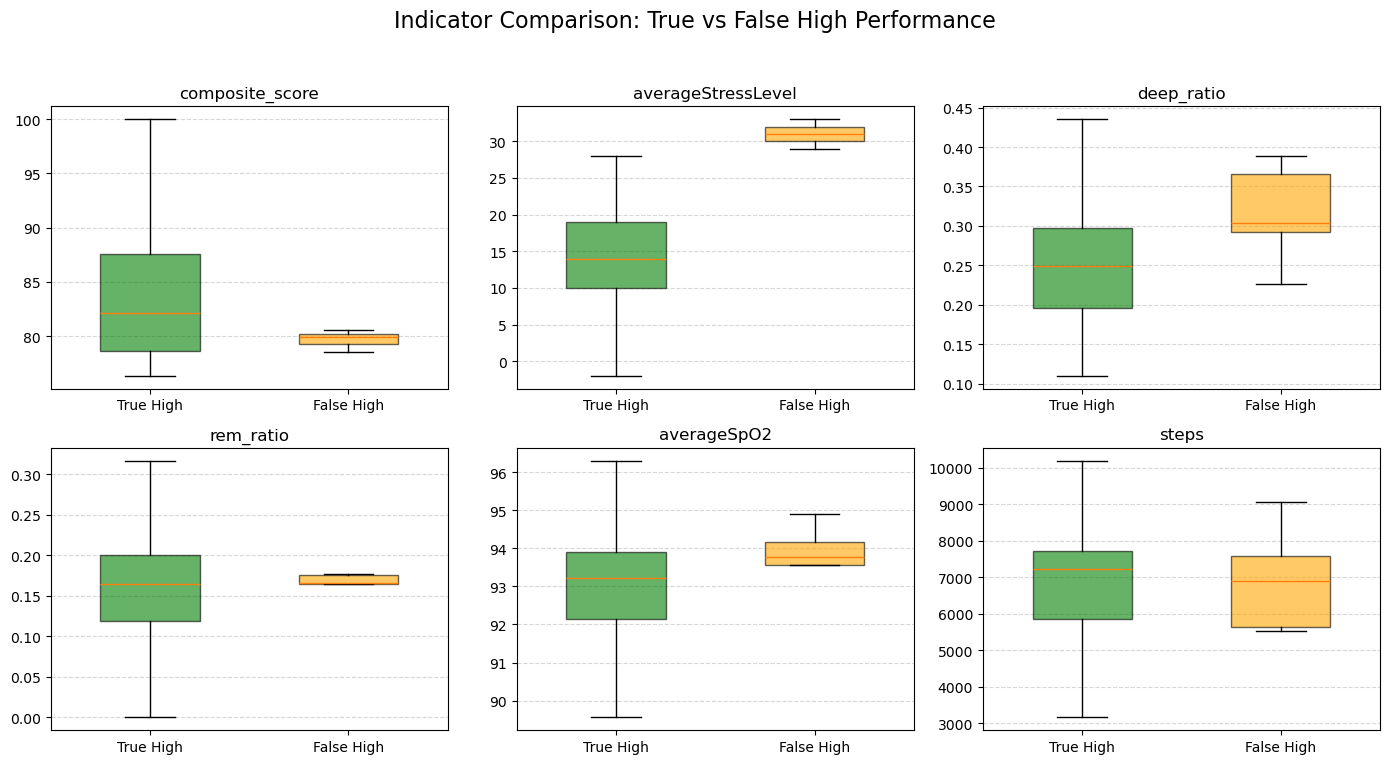

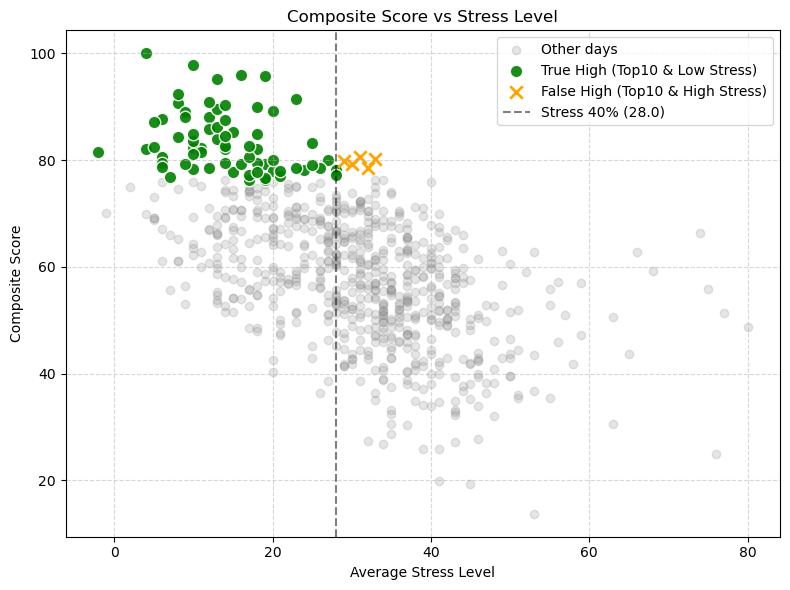

     calendarDate    new_id  composite_score  averageStressLevel  deep_ratio  \
207    2020-04-21  x33563ee       100.000000                 4.0    0.252600   
237    2020-05-21  x33563ee        97.864109                10.0    0.209677   
495    2020-05-17  x33b5ef9        95.941807                16.0    0.263793   
1471   2021-12-01  x437ff9d        95.816878                19.0    0.196501   
744    2020-10-31  x369ff0c        95.192230                13.0    0.352941   
822    2020-10-24  x369ffb1        92.343032                 8.0    0.435247   
1464   2021-11-24  x437ff9d        91.395986                23.0    0.205978   
484    2020-05-06  x33b5ef9        90.944628                12.0    0.259740   
136    2020-05-25  x3355ecf        90.722979                 8.0    0.272336   
535    2020-05-06  x33b5f37        90.291771                14.0    0.295042   
183    2020-05-21  x335606d        89.941162                18.0    0.288160   
482    2020-05-04  x33b5ef9        89.63

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# 必要欄位轉數字
for col in ['averageStressLevel','steps','deep_ratio','rem_ratio','averageSpO2','deep_min','total_sleep_min']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 建立分析子集
hp = df[['calendarDate','new_id','averageStressLevel','steps','deep_ratio','rem_ratio','averageSpO2']].copy()
hp = hp.dropna(subset=['averageStressLevel','steps','deep_ratio','rem_ratio','averageSpO2'])

# 建指標百分位與 activity_score
hp['stress_pct'] = hp['averageStressLevel'].rank(pct=True)
hp['deep_pct'] = hp['deep_ratio'].rank(pct=True)
hp['rem_pct'] = hp['rem_ratio'].rank(pct=True)
hp['spO2_pct'] = hp['averageSpO2'].rank(pct=True)
hp['steps_pct'] = hp['steps'].rank(pct=True)

median_steps_pct = hp['steps_pct'].median()
hp['activity_score'] = 1 - (hp['steps_pct'] - median_steps_pct).abs()*2
hp['activity_score'] = hp['activity_score'].clip(lower=0, upper=1)

# composite score
hp['composite'] = (1 - hp['stress_pct'])*0.25 + hp['activity_score']*0.2 + hp['deep_pct']*0.25 + hp['rem_pct']*0.2 + hp['spO2_pct']*0.1
hp['composite_score'] = hp['composite'] / hp['composite'].max() * 100

# 定義 top 10% 以及壓力低門檻
top_thr = hp['composite_score'].quantile(0.90)
stress_low_thr = hp['averageStressLevel'].quantile(0.40)

hp['is_top10'] = hp['composite_score'] >= top_thr
hp['is_low_stress'] = hp['averageStressLevel'] <= stress_low_thr
hp['true_high_performance'] = hp['is_top10'] & hp['is_low_stress']
hp['false_high_performance'] = hp['is_top10'] & (~hp['is_low_stress'])

# 篩出真/假高效能樣本
true_df = hp[hp['true_high_performance']]
false_df = hp[hp['false_high_performance']]

print("Top10 count:", hp['is_top10'].sum(),
      " True high:", len(true_df),
      " False high:", len(false_df))

# --- 繪圖設定 ---
indicators = ['composite_score','averageStressLevel','deep_ratio','rem_ratio','averageSpO2','steps']
color_true = 'green'
color_false = 'orange'

# 圖表 1：箱型圖 (GridSpec 解決尺度問題)
fig1 = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig1)
# 產生 2x3 = 6 個子圖

axes_list = [fig1.add_subplot(gs[i, j]) for i in range(2) for j in range(3)]

for i, col in enumerate(indicators):
    ax = axes_list[i]
    val_true = true_df[col].dropna().values
    val_false = false_df[col].dropna().values

    # 繪製箱型圖，使用 patch_artist=True 才能填色
    bplot = ax.boxplot([val_true, val_false],
                       positions=[1, 2],
                       patch_artist=True,
                       widths=0.5,
                       showfliers=False)

    # 設定顏色
    colors = [color_true, color_false]
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(col)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['True High', 'False High'])
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig1.suptitle('Indicator Comparison: True vs False High Performance', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('indicators_boxplots.png', dpi=150)
plt.show()

# 圖表 2：散佈圖 (Composite vs Stress)
fig2, ax2 = plt.subplots(figsize=(8, 6))

# 背景 (其他天數)
other_df = hp[~hp['is_top10']]
ax2.scatter(other_df['averageStressLevel'], other_df['composite_score'],
            c='gray', alpha=0.2, label='Other days')

# True High (Green Circle)
if not true_df.empty:
    ax2.scatter(true_df['averageStressLevel'], true_df['composite_score'],
                c=color_true, marker='o', s=80, edgecolors='white', alpha=0.9,
                label='True High (Top10 & Low Stress)')

# False High (Orange X)
if not false_df.empty:
    ax2.scatter(false_df['averageStressLevel'], false_df['composite_score'],
                c=color_false, marker='x', s=80, linewidths=2, alpha=1.0,
                label='False High (Top10 & High Stress)')

# 壓力閾值線
ax2.axvline(stress_low_thr, linestyle='--', color='black', alpha=0.5,
            label=f'Stress 40% ({stress_low_thr:.1f})')

ax2.set_xlabel('Average Stress Level')
ax2.set_ylabel('Composite Score')
ax2.set_title('Composite Score vs Stress Level')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('composite_vs_stress_scatter.png', dpi=150)
plt.show()

# 列出 Top 10 資料表
top10_table = hp[hp['is_top10']].sort_values('composite_score', ascending=False)
print(top10_table[['calendarDate','new_id','composite_score','averageStressLevel','deep_ratio','rem_ratio','steps','averageSpO2','true_high_performance','false_high_performance']].head(20))